In [53]:
from google.colab import drive
drive.mount('/content/drive')

!pip install timm


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
import h5py
import numpy as np
import random
import time
import torchvision.transforms.functional as TF

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

import cv2
from google.colab import files

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [55]:
TRAIN_H5 = "/content/drive/MyDrive/morph_project/processed/train.h5"
TEST_H5  = "/content/drive/MyDrive/morph_project/processed/test.h5"
SAVE_PATH = "/content/drive/MyDrive/morph_project/models/efficientnet_b3_tuned_baseline.pth"


In [56]:
class H5Dataset(Dataset):
    def __init__(self, h5_path, train=False, augment_prob=0.5):
        self.h5 = h5py.File(h5_path, "r")
        self.X = self.h5["X"]    # (N,224,224,3), float32, already standardized
        self.y = self.h5["y"]
        self.train = train
        self.augment_prob = augment_prob

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        img = self.X[idx]   # HWC
        label = int(self.y[idx])

        img_t = torch.from_numpy(img).permute(2,0,1).float()

        if self.train:
            # horizontal flip
            if random.random() < self.augment_prob:
                img_t = torch.flip(img_t, dims=[2])

            # small rotation
            if random.random() < (self.augment_prob * 0.3):
                angle = random.uniform(-10, 10)
                img_t = TF.rotate(img_t, angle)

        return img_t, torch.tensor(label, dtype=torch.long)


In [57]:
train_ds = H5Dataset(TRAIN_H5, train=True, augment_prob=0.5)
test_ds  = H5Dataset(TEST_H5, train=False, augment_prob=0.0)

print("Train size:", len(train_ds))
print("Test size:", len(test_ds))

train_labels = np.array(train_ds.y)
class_counts = np.bincount(train_labels)
print("Class counts:", class_counts)

class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]
sample_weights = torch.tensor(sample_weights, dtype=torch.double)

sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print("Train batches:", len(train_loader), "Val batches:", len(val_loader))


Train size: 7177
Test size: 1803
Class counts: [5946 1231]
Train batches: 225 Val batches: 57


In [58]:
model = timm.create_model(
    "tf_efficientnet_b3_ns",
    pretrained=True,
    num_classes=2
).to(device)

print(model.classifier)  # just to see the head once


Linear(in_features=1536, out_features=2, bias=True)


In [59]:
AU, TP = class_counts[0], class_counts[1]
total = AU + TP

w_au = total / (2 * AU)
w_tp = total / (2 * TP)
class_w = torch.tensor([w_au, w_tp], device=device, dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=class_w)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

scaler = torch.cuda.amp.GradScaler()


/tmp/ipython-input-1430107164.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [60]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def validate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


In [61]:
EPOCHS = 10
best_val_acc = 0.0

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc*100:.2f}%")
    print(f"Time: {time.time() - t0:.1f} sec")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"🔥 Saved BEST model (Val Acc: {val_acc*100:.2f}%) to {SAVE_PATH}")

print("\nTraining complete!")


/tmp/ipython-input-3983964160.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 1/10
Train Loss: 0.7083 | Train Acc: 66.77%
Val   Loss: 1.0828 | Val   Acc: 66.00%
Time: 140.8 sec
🔥 Saved BEST model (Val Acc: 66.00%) to /content/drive/MyDrive/morph_project/models/efficientnet_b3_tuned_baseline.pth

Epoch 2/10
Train Loss: 0.2907 | Train Acc: 81.44%
Val   Loss: 1.1599 | Val   Acc: 66.00%
Time: 100.9 sec

Epoch 3/10
Train Loss: 0.1901 | Train Acc: 87.07%
Val   Loss: 0.9348 | Val   Acc: 72.77%
Time: 100.3 sec
🔥 Saved BEST model (Val Acc: 72.77%) to /content/drive/MyDrive/morph_project/models/efficientnet_b3_tuned_baseline.pth

Epoch 4/10
Train Loss: 0.1502 | Train Acc: 91.08%
Val   Loss: 0.9509 | Val   Acc: 74.43%
Time: 99.2 sec
🔥 Saved BEST model (Val Acc: 74.43%) to /content/drive/MyDrive/morph_project/models/efficientnet_b3_tuned_baseline.pth

Epoch 5/10
Train Loss: 0.1333 | Train Acc: 91.92%
Val   Loss: 0.8307 | Val   Acc: 77.81%
Time: 99.9 sec
🔥 Saved BEST model (Val Acc: 77.81%) to /content/drive/MyDrive/morph_project/models/efficientnet_b3_tuned_baseline.

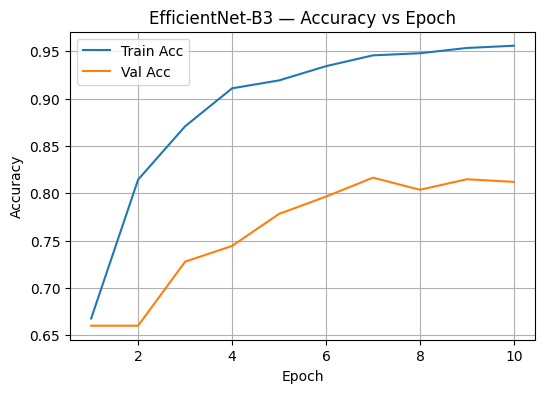

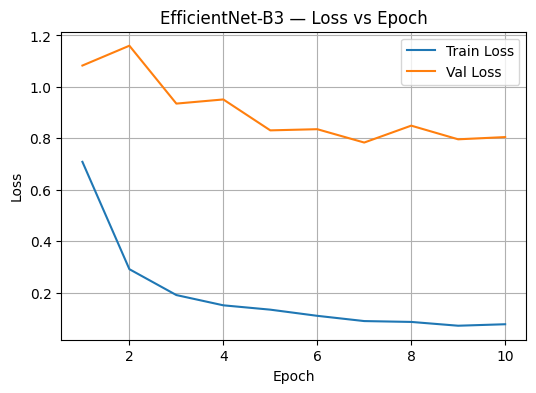

In [63]:
epochs = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("EfficientNet-B3 — Accuracy vs Epoch")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("EfficientNet-B3 — Loss vs Epoch")
plt.legend(); plt.grid(True); plt.show()


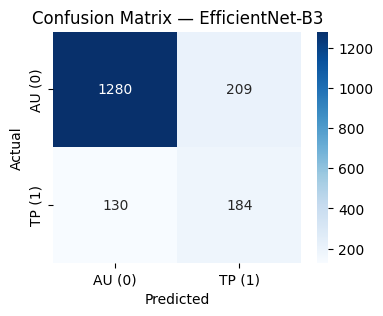

In [64]:
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["AU (0)", "TP (1)"],
            yticklabels=["AU (0)", "TP (1)"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — EfficientNet-B3")
plt.show()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


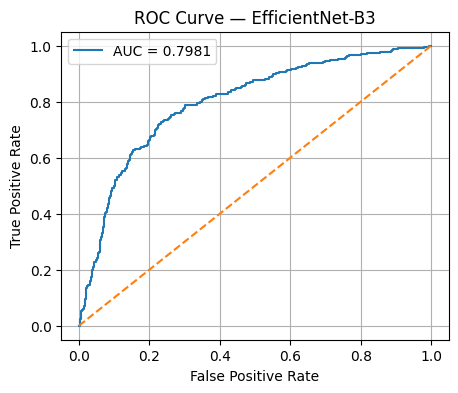

In [65]:
y_true, y_prob = [], []

model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1]

        y_true.extend(labels.numpy())
        y_prob.extend(probs.cpu().numpy())

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — EfficientNet-B3")
plt.legend(); plt.grid(True); plt.show()


In [66]:
MEAN = 0.023676937445998192
STD  = 0.9749630689620972

def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    img = img.astype(np.float32) / 255.0
    img = (img - MEAN) / (STD + 1e-7)

    img = torch.tensor(img).permute(2,0,1).float().unsqueeze(0)
    return img.to(device)


In [67]:
# Load best model
model_inf = timm.create_model(
    "tf_efficientnet_b3_ns",
    pretrained=False,
    num_classes=2
).to(device)

model_inf.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model_inf.eval()
print("✅ Inference model loaded!")


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name tf_efficientnet_b3_ns to current tf_efficientnet_b3.ns_jft_in1k.
  model = create_fn(


✅ Inference model loaded!


In [68]:
def predict_image(path):
    img = preprocess_image(path)
    with torch.no_grad():
        out = model_inf(img)
        probs = torch.softmax(out, dim=1)[0]

    pred = probs.argmax().item()
    conf = float(probs[pred] * 100)

    label = "Authentic (AU, 0)" if pred == 0 else "Tampered (TP, 1)"

    print("\n===========================")
    print(f"IMAGE: {path}")
    print(f"PREDICTION: {label}")
    print(f"CONFIDENCE: {conf:.2f}%")
    print("===========================\n")


In [72]:
uploaded = files.upload()
for name in uploaded.keys():
    predict_image(name)


Saving img4.png to img4.png

IMAGE: img4.png
PREDICTION: Tampered (TP, 1)
CONFIDENCE: 97.84%

